Poids classe positive : 5.705730288668677


C:\Users\ATOMIQ\PyCharmMiscProject\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:15:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


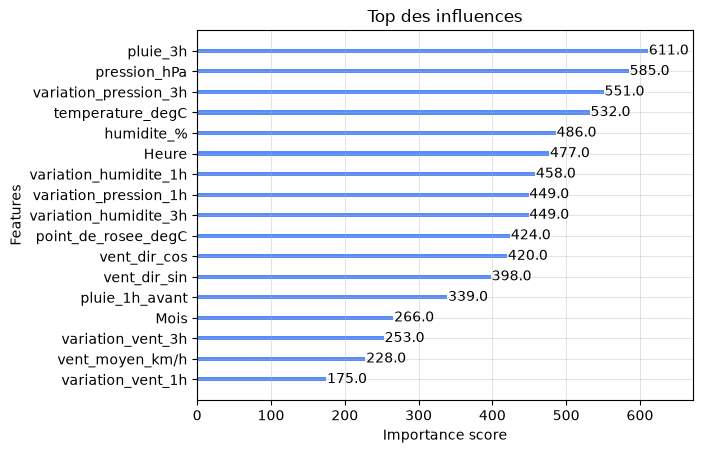


RMSE : 0.1279
MAE  : 0.0258
Accuracy : 0.9784117193523516
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3311
           1       0.90      0.96      0.93       580

    accuracy                           0.98      3891
   macro avg       0.95      0.97      0.96      3891
weighted avg       0.98      0.98      0.98      3891


Modèle sauvegardé sous 'modele_prediction_pluie_V2.json'


In [2]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Chargement du dataset enrichi métriques completes de 2025 + les métriques de pluie de 2024.
df = pd.read_csv("donnees_meteo_2025_NETTOYEES_V2.csv", sep=";")

# Conserver le format datetime :
df["dh_utc"] = pd.to_datetime(df["dh_utc"], dayfirst=True)

# Création de variables temporelles :
df["Mois"] = df["dh_utc"].dt.month
df["Heure"] = df["dh_utc"].dt.hour


# Création de variables permettant de détecter des changements associés à l'arrivée de pluie :
df["variation_pression_3h"] = df["pression_hPa"] - df["pression_hPa"].shift(3)
df["variation_humidite_3h"] = df["humidite_%"] - df["humidite_%"].shift(3)
df["variation_vent_3h"] = df["vent_moyen_km/h"] - df["vent_moyen_km/h"].shift(3)
df["variation_pression_1h"] = df["pression_hPa"] - df["pression_hPa"].shift(1)
df["variation_humidite_1h"] = df["humidite_%"] - df["humidite_%"].shift(1)
df["variation_vent_1h"] = df["vent_moyen_km/h"] - df["vent_moyen_km/h"].shift(1)

# Création de variables historique pluie :
df["pluie_1h_avant"] = df["pluie_1h_mm"].shift(1)
df["pluie_3h"] = df["pluie_1h_mm"].rolling(3).sum()

# Vent encodé (ref : https://stackoverflow.com/questions/28077733/numpy-sin-function-in-degrees) :
df["vent_dir_sin"] = np.sin(df["vent_direction_deg"] * np.pi / 180)
df["vent_dir_cos"] = np.cos(df["vent_direction_deg"] * np.pi / 180)

# Suppression des lignes contenant des valeurs manquantes :
df = df.dropna()

# On supprime les colonnes non pertinentes :
X = df.drop(columns=[
    "pleut_il", # variable cible
    "station_id",
    "dh_utc",
    "vent_direction_deg", # remplacée par sin/cos
    "pluie_1h_mm"
])

# Variable cible :
y = df["pleut_il"]

# Séparation en données d'entraînement et de test :
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cette technique permet d'amoindrir le déséquilibre entre les classes. Plus la pluie est rare, plus son poids sera élevé.
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
print("Poids classe positive :", scale_pos_weight)

# Création du modèle XGBoost optimisé.
# Plusieurs paramètres ont été ajustés pour améliorer la généralisation du modèle :
model = XGBClassifier(
    n_estimators=400, # nombre d'arbres plus élevé
    max_depth=5, # Arbres moins profonds (limite le surapprentissage).
    learning_rate=0.05, #Apprentissage plus progressif.
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight, # Pondération du déséquilibre.
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

# Entraînement du modèle :
model.fit(X_train, y_train)

# Calcul des probabilités de pluie :
y_proba = model.predict_proba(X_test)[:, 1]

# Le seuil est volontairement ajusté à 0.65 pour mieux contrôler le compromis entre détection et faux positifs.
threshold = 0.65
y_pred = (y_proba > threshold).astype(int)

#Calcul de nos indicateurs qualités :
rmse = np.sqrt(mean_squared_error(y_test, y_proba))
mae = mean_absolute_error(y_test, y_proba)

# Visualisation de l'importance des variables :
xgb.plot_importance(model)
plt.title("Top des influences")
plt.show()

# Affichage des perfs :
print(f"\nRMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print("Accuracy :", accuracy_score(y_test, y_pred))

# Rapport détaillé permettant d'analyser les performances sur chaque classe :
print(classification_report(y_test, y_pred))

# Sauvegarder de notre modèle :
model.save_model('modele_prediction_pluie_V2.json')
print("\nModèle sauvegardé sous 'modele_prediction_pluie_V2.json'")